<a href="https://colab.research.google.com/github/T2data/Data_projects_TripleTen/blob/main/sprint4_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 4 Project: E-Commerce Customer Behavior EDA

Welcome to your Sprint 4 final project. In this project, you will apply everything you've learned across Sprints 1–4 to perform a complete Exploratory Data Analysis on the **Olist Brazilian E-Commerce dataset** — real data from a real e-commerce platform.


## Dataset

You'll work with 7 CSV files from the Olist e-commerce dataset:

| File | Rows | Description |
|---|---|---|
| `olist_orders_dataset.csv` | 99,441 | Orders with timestamps and status |
| `olist_order_items_dataset.csv` | 112,650 | Items per order with price and freight |
| `olist_customers_dataset.csv` | 99,441 | Customer ID, city, state |
| `olist_products_dataset.csv` | 32,951 | Products with category and dimensions |
| `olist_order_reviews_dataset.csv` | 99,224 | Review scores (1–5 stars) |
| `olist_order_payments_dataset.csv` | 103,886 | Payment type and value |
| `product_category_name_translation.csv` | 71 | Portuguese → English category names |

Let's get started!

---

## Setup

Run the cells below to import the libraries you'll need and load the datasets. The data is hosted on GitHub, so you can load it with one line of code per file — no uploads required.

In [31]:
# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Confirm versions
print(f"pandas version: {pd.__version__}")
print("Setup complete!")

pandas version: 2.2.2
Setup complete!


In [32]:
# Load the 7 datasets from the curriculum GitHub repo
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [33]:
# Set up an in-memory SQLite database with all 7 tables
# This lets you run SQL queries directly against the DataFrames
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
translation.to_sql('translation', conn, index=False, if_exists='replace')

print("SQLite database ready. You can now run SQL queries with pd.read_sql().")

SQLite database ready. You can now run SQL queries with pd.read_sql().


---

## Question 1: Inspect the orders DataFrame

**Your task:** For the `orders` DataFrame:
1. Print its shape
2. Print the first 5 rows with `.head()`
3. Print column info with `.info()`

This is the very first thing every analyst does with a new dataset.

*Skills: Sprint 4 Ch 01 (Pandas inspection)*

In [34]:
# Your code here
#Print its shape
print(orders.shape)

#Print the first 5 rows
print(orders.head())

#Print column info
print(orders.info())

(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

---

## Question 2: Clean the orders data

The `orders` DataFrame has timestamp columns stored as strings, and a few have missing values.

**Your task:**
1. Use `.isnull().sum()` to count missing values in each column of `orders`
2. Convert `order_purchase_timestamp` and `order_delivered_customer_date` to datetime using `pd.to_datetime()`
3. Print the dtypes after conversion to verify

*Skills: Sprint 4 Ch 02 (Cleaning, dtype conversion)*

In [35]:
# Your code here
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [36]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'],errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
print(type(orders['order_purchase_timestamp']))
print(type(orders['order_delivered_customer_date']))


<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


---

## Question 3: Order status breakdown (SQL)

**Your task:** Write a SQL query against the `orders` table that returns:
- `order_status`
- `num_orders` — count of orders with that status
- `pct` — percentage of total orders, rounded to 2 decimals

Sort by `num_orders` descending. Save the result to a DataFrame called `status_summary` and print it.

**Hint:** Use `pd.read_sql("...", conn)`. The percentage trick is `COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders)`.

*Skills: Sprint 2 (SQL aggregation), Sprint 4 Ch 03 (Descriptive stats)*

In [37]:
# Your code here
query = '''
          select order_status, count(*) as num_orders,
          round(count(*)*100/(select count(*)from orders),2) as pct
          from orders
          group by order_status
          order by num_orders desc
        '''
status_summary = pd.read_sql(query,conn)
print(status_summary)


  order_status  num_orders   pct
0    delivered       96478  97.0
1      shipped        1107   1.0
2     canceled         625   0.0
3  unavailable         609   0.0
4     invoiced         314   0.0
5   processing         301   0.0
6      created           5   0.0
7     approved           2   0.0


---

## Question 4: Top 10 highest-revenue orders (SQL JOIN)

Each order can have multiple items. Total order revenue = sum of `price + freight_value` across all its items.

**Your task:** Write a SQL query that JOINs `orders` and `items` to find the **10 highest-revenue orders**. Return:
- `order_id`
- `order_status`
- `total_revenue` — rounded to 2 decimals

Save the result to `top_orders` and print it.

*Skills: Sprint 2 (SQL JOIN, GROUP BY), Sprint 4 Ch 06 (combining tables)*

In [38]:
# Your code here
top_orders = None
query = '''select o.order_id, o.order_status,
           round((i.price + i.freight_value),2) as total_revenue
           from orders o, items i
           on (i.order_id = o.order_id)
           order by total_revenue desc limit 10
        '''
top_orders = pd.read_sql(query,conn)
print(top_orders)

                           order_id order_status  total_revenue
0  0812eb902a67711a1cb742b3cdaa65ae    delivered        6929.31
1  fefacc66af859508bf1a7934eab1e97f    delivered        6922.21
2  f5136e38d1a14a4dbd87dff67da82701    delivered        6726.66
3  a96610ab360d42a2e5335a3998b4718a    delivered        4950.34
4  199af31afc78c699f0dbf71fb178d4d4    delivered        4764.34
5  8dbc85d1447242f3b127dda390d56e19    delivered        4681.78
6  426a9742b533fc6fed17d1fd6d143d7e    delivered        4513.32
7  80dfedb6d17bf23539beeef3c768f4d7    delivered        4194.76
8  68101694e5c5dc7330c91e1bbc36214f    delivered        4175.26
9  b239ca7cd485940b31882363b52e6674    delivered        4163.51


---

## Question 5: English product categories (pandas merge)

The `products` table has a Portuguese category column called `product_category_name`. The `translation` table maps each Portuguese name to its English equivalent.

**Your task:**
1. Use `products.merge(translation, on='product_category_name', how='left')` to add the English column. Save it to `products_eng`.
2. Find the **top 10 categories by number of products** using `value_counts()` on the `product_category_name_english` column. Save to `top_categories` and print it.

*Skills: Sprint 4 Ch 06 (pandas merge), Ch 03 (value_counts)*

In [39]:
# Your code here
products_eng = products.merge(translation, on = 'product_category_name', how='left')
top_categories = products_eng['product_category_name_english'].value_counts()
print(top_categories.head(10))

product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


---

## Question 6: Revenue and average review score by category

Now you'll combine three tables and compute multiple metrics per category.

**Your task:**
1. Build a DataFrame that merges `items` with `products_eng` (to get categories), then merges with `reviews` (to get scores). The shared key chain is: `items.product_id → products_eng.product_id` and `items.order_id → reviews.order_id`.
2. Add a `revenue` column = `price + freight_value`
3. Group by `product_category_name_english` and aggregate:
   - `total_revenue` = sum of `revenue`
   - `avg_review` = mean of `review_score`
   - `n_items` = count of `order_id`
4. Sort by `total_revenue` descending and show the **top 10 categories**. Save to `category_summary`.

*Skills: Sprint 4 Ch 06 (multi-table merge, groupby with multiple aggregations)*

In [40]:
categories_df= items.merge(products_eng, on = 'product_id', how='left')
score_df= categories_df.merge(reviews, on='order_id', how='left')
score_df['revenue']= (score_df['price'] + score_df['freight_value'])
prod_grp = score_df.groupby('product_category_name_english')
agg_dict={'revenue':'sum','review_score':'mean', 'order_id':'count'}
category_summary= prod_grp.agg(agg_dict).sort_values(by='revenue', ascending=False)
category_summary = category_summary.rename(columns={'revenue':'total_revenue','review_score':'avg_review', 'order_id':'n_items'})
print(category_summary.head(10))

                               total_revenue  avg_review  n_items
product_category_name_english                                    
health_beauty                     1446622.08    4.142768     9727
watches_gifts                     1306761.40    4.019160     6001
bed_bath_table                    1258189.51    3.895663    11270
sports_leisure                    1163329.98    4.107986     8700
computers_accessories             1068070.48    3.930819     7894
furniture_decor                    910683.05    3.903493     8415
housewares                         781170.03    4.055019     6989
cool_stuff                         721492.90    4.146341     3806
auto                               687374.19    4.065512     4256
garden_tools                       585646.54    4.042735     4361


---

## Question 7: Top 10 customer states (SQL + bar chart)

**Your task:**
1. Write a SQL query that returns the **top 10 customer states** by number of customers. Columns: `customer_state`, `num_customers`. Save to `state_top10`.
2. Create a **bar chart** of `num_customers` by `customer_state`. Add a title and rotate the x-tick labels if they overlap.

*Skills: Sprint 2 (SQL GROUP BY), Sprint 4 Ch 04 (bar chart)*

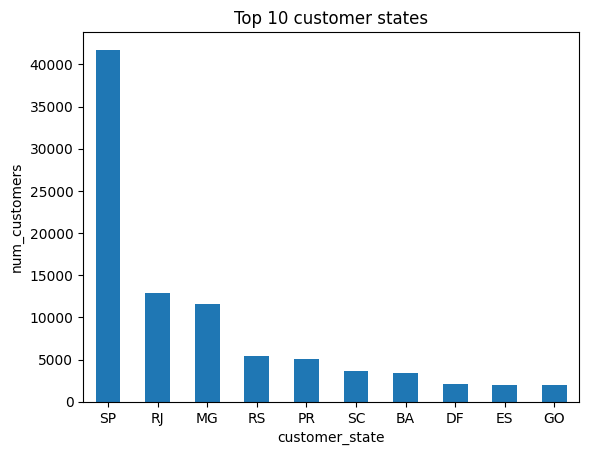

In [41]:
# Your code here
query = '''
            select customer_state, count(*) as num_customers
            from customers
            group by customer_state
            order by num_customers desc limit 10
        '''
state_top10 = pd.read_sql(query, conn)
state_top10.plot(x='customer_state',kind='bar',title='Top 10 customer states',legend=False)
plt.ylabel('num_customers')
plt.xlabel('customer_state')
plt.xticks(rotation=0)
plt.show()


---

## Question 8: Monthly order trend (line chart)

**Your task:**
1. From the cleaned `orders` DataFrame (with datetime columns from Q2), extract a `year_month` period from `order_purchase_timestamp` using `.dt.to_period('M')`
2. Count orders per month — save to a DataFrame called `monthly_orders` with columns `year_month` and `num_orders`
3. Plot a **line chart** of `num_orders` over time. Add a title.

**Hint:** `orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()` is a fast way to get monthly counts. Convert the period index back to string for plotting.

*Skills: Sprint 4 Ch 02 (datetime), Ch 03 (groupby), Ch 04 (line chart)*

   year_month  num_orders
0     2017-11        7544
1     2018-01        7269
2     2018-03        7211
3     2018-04        6939
4     2018-05        6873
5     2018-02        6728
6     2018-08        6512
7     2018-07        6292
8     2018-06        6167
9     2017-12        5673
10    2017-10        4631
11    2017-08        4331
12    2017-09        4285
13    2017-07        4026
14    2017-05        3700
15    2017-06        3245
16    2017-03        2682
17    2017-04        2404
18    2017-02        1780
19    2017-01         800
20    2016-10         324
21    2018-09          16
22    2016-09           4
23    2018-10           4
24    2016-12           1


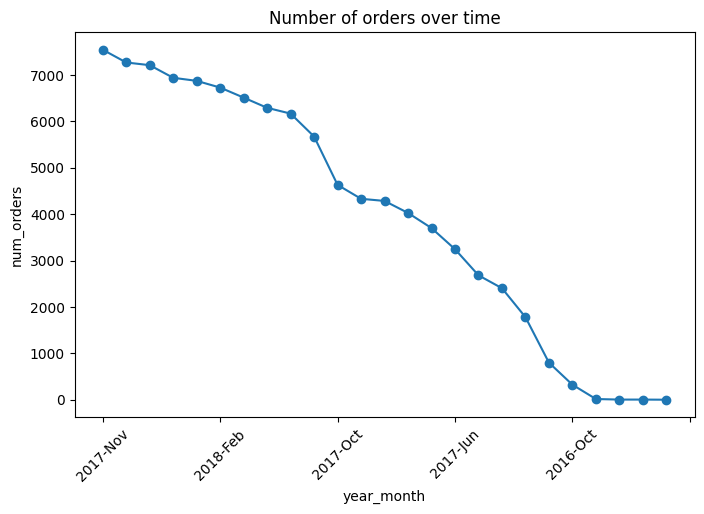

In [42]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
monthly_orders  = orders['order_purchase_timestamp'].dt.to_period('M').value_counts().reset_index()
monthly_orders .columns = ['year_month', 'num_orders']
print(monthly_orders)
monthly_orders['date_str'] = monthly_orders['year_month'].dt.strftime('%Y-%b')
monthly_orders.set_index('date_str', inplace=True)
monthly_orders['num_orders'].plot(kind='line', marker='o', figsize=(8, 5))
plt.title('Number of orders over time')
plt.xlabel('year_month')
plt.ylabel('num_orders')
plt.xticks(rotation=45)
plt.show()

In [43]:
data = {'dates': ['2025-01-15', '2025-01-20', '2025-02-10', '2025-02-15', '2025-02-25', '2025-03-05']}
df = pd.DataFrame(data)

# Convert string dates to datetime
df['dates'] = pd.to_datetime(df['dates'])

# 2 & 3. Extract month, count, and convert to DataFrame
monthly_counts = df['dates'].dt.to_period('M').value_counts().reset_index()

# Rename columns for clarity
monthly_counts.columns = ['Month', 'Count']

print(monthly_counts)

     Month  Count
0  2025-02      3
1  2025-01      2
2  2025-03      1


---

## Question 9: Does delivery speed affect review scores?

This is a real business question: do customers who get their orders faster leave better reviews?

**Your task:**
1. From `orders`, keep only rows where `order_delivered_customer_date` is not null
2. Add a `delivery_days` column = (delivery date − purchase date) in days. **Hint:** subtract the two datetime columns and use `.dt.days`
3. Merge with `reviews` on `order_id` to get the `review_score` for each order
4. Compute the **correlation** between `delivery_days` and `review_score` using `.corr()`
5. Group by `review_score` and show the **average delivery days** for each score (1 through 5)
6. Plot a bar chart of average delivery days by review score

What pattern do you see? Add a markdown cell with your interpretation.

*Skills: Sprint 4 Ch 03 (correlation), Ch 04 (visualization), Ch 06 (merge + groupby)*

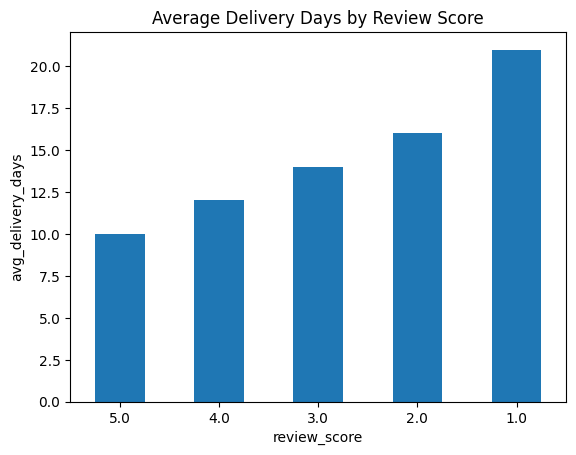

correlation between delivery_days and review_score: -0.333660341104771


In [44]:
# Your code here
pd.options.mode.chained_assignment = None
orders_clean = orders.dropna(subset=['order_delivered_customer_date'])
orders_clean['delivery_days'] = (orders_clean['order_delivered_customer_date']-orders_clean['order_purchase_timestamp']).dt.days
review_order = orders_clean.merge(reviews, on='order_id',how='left')
delivery_days_review_score_correlation = review_order['delivery_days'].corr(review_order['review_score'])
rev_Score_grp =review_order.groupby('review_score')
avg_deli_days_by_review_score = round(rev_Score_grp.agg({'delivery_days':'mean'}),0).sort_values(by='review_score',ascending=False)
avg_deli_days_by_review_score.plot(kind='bar', title='Average Delivery Days by Review Score',legend= False)
plt.ylabel('avg_delivery_days')
plt.xlabel('review_score')
plt.xticks(rotation=0)
plt.show()
agg_dic = {'delivery_days':'mean'}
print(f"correlation between delivery_days and review_score: {delivery_days_review_score_correlation}")

**correlation between delivery_days and review_score:**

*There is an inverse correlation of (-0.3) between delivery speed and customer ratings. This indicates that longer delivery times correspond to lower feedback scores, a pattern that is also visible in the bar chart.*

---

## Question 10: Final Report

Write a **2–3 paragraph executive summary** of your findings as a markdown cell below. A good report answers:

- **What is the overall health of the business?** (Use Q3, Q8 — order volumes and trends)
- **Which product categories should we double down on?** (Use Q6 — revenue + review scores together)
- **Where are our customers and how do we serve them?** (Use Q7, Q9 — geography and delivery speed)
- **What is one specific recommendation you would make to the leadership team?**

Write as if you're presenting to a non-technical executive. Use plain language. Reference specific numbers from your analysis.

*Skills: Sprint 4 Ch 06 (analytical reporting)*

## Executive Summary

### Business Health
- **Delivery Success:** Achieved a ~97% success rate, with 96,478 out of 99,441 orders delivered without issue, reflecting strong operational performance.

- **Volume Growth:** Monthly charts highlights a steady upward trend in overall order volume over time.


### Top Categories
- Data indicates that **Health & Beauty, Watches & Gifts, and Sports & Leisure** are our top three categories for both revenue and customer reviews. We should heavily focus on doubling down on these product categories.

### Customer Geography & Delivery
- Most of our customer base is concentrated in São Paulo (SP), Rio de Janeiro (RJ), and Minas Gerais (MG), with SP being our top market, This distribution is clearly reflected in the accompanying bar chart.

### Recommendation
- **Customer Experience:** Investigate and resolve the issues causing slower deliveries to receive lower ratings, thereby increasing buyer satisfaction.
- **Geographic Expansion:** Target new market growth in regions outside of São Paulo, Rio de Janeiro, and Minas Gerais.
- **Category Focus:** Dedicate operational and marketing resources to capitalize on top-performing product categories like Sports & Leisure, Watches & Gifts, and Health & Beauty.